# Reto 1: cerebro de un robot seguidor de línea (simulador)

Este notebook simula el reto completo:

```
 ┌──────────── PISTA (vista desde arriba) ────────────┐
 │   línea negra + octágono rojo (PARE) + verde (SIGA) │
 │                                                     │
 │        robot ──► cuadro de vista (lo que ve)        │
 └─────────────────────────────────────────────────────┘
                 │ imagen de la cámara
                 ▼
     CEREBRO (visión artificial)  →  velocidad llanta izquierda / derecha
                 │
                 ▼
     el robot se mueve en la pista  →  nueva imagen  →  ...
```

El **cerebro** solo recibe la imagen de la cámara, igual que el robot real con el celular. No sabe dónde está la pista ni dónde están las señales: todo lo deduce de la imagen.

Solo usa técnicas del curso (sin redes neuronales ni modelos entrenados):

| Etapa | Técnicas | Viene de |
| ----- | -------- | -------- |
| 1. Encontrar la línea | Espacio **HSV**, **umbralización**, **morfología**, **región de interés (ROI)** | notebook 3 |
| 2. Dirección | **Contornos** y **centroides** por franjas → error respecto al centro | notebook 5 |
| 3. Señales | **Segmentación por color** (OR de dos rangos para el rojo), **aproximación poligonal** (8 vértices), solidez, circularidad | notebooks 3 y 5 |
| 4. Decisión | Control proporcional-derivativo + máquina de estados (SIGUIENDO / PARE / SIGA / BUSCANDO) | nuevo |

Al final hay una sección para usar el mismo cerebro con la cámara real.

In [1]:
import sys
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt


EN_COLAB = "google.colab" in sys.modules

## Configuración

Todos los valores ajustables están aquí.

In [2]:
# ================= CEREBRO (visión) =================

# Línea
ROI_INICIO = 0.45       # la zona de análisis empieza en el 45 % de la altura de la imagen
N_FRANJAS = 3           # la ROI se divide en franjas horizontales
PESOS_FRANJAS = [0.2, 0.3, 0.5]  # peso de cada franja en el error (de arriba hacia abajo)
V_MAX_LINEA = 90        # brillo máximo (V) de un píxel de la línea negra
S_MAX_LINEA = 90        # saturación máxima (S): la línea es negra, no de color
AREA_MIN_LINEA = 150    # área mínima (px) de un trozo de línea en una franja

# Señales
ROJO_1 = ((0, 100, 70), (10, 255, 255))      # el rojo está en los dos extremos del tono H
ROJO_2 = ((170, 100, 70), (179, 255, 255))
VERDE = ((40, 80, 50), (85, 255, 255))
AREA_MIN_SENAL = 0.004  # fracción de la imagen para considerar un objeto como posible señal
SENAL_Y_CERCA = 0.5     # la señal está "cerca" cuando su centro pasa de la mitad de la imagen hacia abajo
CUADROS_CONFIRMAR = 3   # cuadros seguidos viendo la señal antes de reaccionar

# Comportamiento
TIEMPO_PARE = 3.0       # segundos detenido ante PARE (lo define el docente)

# Control de las llantas (escala -100 a 100)
VEL_BASE = 60
VEL_MAX = 100
KP = 55                 # cuánto gira según el error
KD = 25                 # amortigua el giro según el cambio del error
VEL_BUSQUEDA = 35       # velocidad de giro cuando se pierde la línea


# ================= SIMULADOR =================

MAPA_ANCHO, MAPA_ALTO = 1400, 1000
GROSOR_LINEA = 28       # px en el mapa
RADIO_SENAL = 26        # px en el mapa

DT = 1 / 30             # segundos por paso de simulación (30 cuadros por segundo)
ESCALA_VEL = 2.0        # velocidad 100 = 200 px/s en el mapa
DIST_LLANTAS = 50       # distancia entre las llantas (px)

# Cuadro de vista de la cámara (en px del mapa, delante del robot)
CAM_CERCA, CAM_LEJOS = 40, 260          # distancia al borde cercano y al lejano
CAM_ANCHO_CERCA, CAM_ANCHO_LEJOS = 180, 340
CAM_W, CAM_H = 640, 480                 # tamaño de la imagen que recibe el cerebro

LIMITE_DESCARRILA = 45  # px: si el robot se aleja más que esto de la línea, se cuenta un descarrilamiento

# 1. Encontrar la línea

La línea es **negra**: en HSV tiene **brillo bajo (V)** y **saturación baja (S)**. Pedir las dos condiciones evita confundirla con una sombra o con el verde oscuro de una señal:

```python
linea = cv2.inRange(hsv, (0, 0, 0), (179, S_MAX_LINEA, V_MAX_LINEA))
```

`inRange` es una umbralización con un **AND** de las tres condiciones. Después:

* **Apertura** (erosión + dilatación) elimina puntos sueltos.
* **Cierre** (dilatación + erosión) rellena huecos pequeños.

In [3]:
def mascara_linea(cuadro):
    suave = cv2.GaussianBlur(cuadro, (5, 5), 0)
    hsv = cv2.cvtColor(suave, cv2.COLOR_BGR2HSV)

    mascara = cv2.inRange(hsv, (0, 0, 0), (179, S_MAX_LINEA, V_MAX_LINEA))

    kernel = np.ones((5, 5), np.uint8)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

    return mascara

# 2. Dirección del movimiento

Solo se analiza la **parte baja** de la imagen (ROI): es el piso justo delante del robot.

La ROI se divide en `N_FRANJAS` franjas horizontales. En cada franja:

1. Se buscan los **contornos** de la línea.
2. Se calcula el **centroide** con los momentos: $c_x = M_{10} / M_{00}$.
3. Si hay varios trozos, se elige el más cercano al de la franja de abajo, para no saltar a otra parte de la pista.

Con los centroides se calcula el **error**, que es qué tan lejos está la línea del centro del robot:

$$\text{error} = \frac{c_x - \text{centro}}{\text{centro}} \quad\in [-1, 1]$$

* error < 0 → la línea está a la izquierda → girar a la izquierda.
* error > 0 → la línea está a la derecha → girar a la derecha.

El error final es un promedio ponderado. La franja de abajo pesa más (es donde está el robot ahora), pero las de arriba permiten **anticipar las curvas**.

In [4]:
def detectar_linea(cuadro, x_anterior=None):
    alto, ancho = cuadro.shape[:2]
    centro = ancho / 2

    mascara = mascara_linea(cuadro)

    y_inicio = int(alto * ROI_INICIO)
    alto_franja = (alto - y_inicio) // N_FRANJAS

    # De abajo hacia arriba: cada franja sigue a la de abajo
    x_referencia = centro if x_anterior is None else x_anterior
    puntos = [None] * N_FRANJAS

    for i in reversed(range(N_FRANJAS)):
        y_a = y_inicio + i * alto_franja
        franja = mascara[y_a:y_a + alto_franja]

        contornos, _ = cv2.findContours(franja, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        candidatos = []

        for contorno in contornos:
            if cv2.contourArea(contorno) < AREA_MIN_LINEA:
                continue

            m = cv2.moments(contorno)
            candidatos.append((m["m10"] / m["m00"], m["m01"] / m["m00"] + y_a))

        if candidatos:
            punto = min(candidatos, key=lambda p: abs(p[0] - x_referencia))
            puntos[i] = punto
            x_referencia = punto[0]

    resultado = {
        "encontrada": False, "error": 0.0, "x_abajo": None,
        "puntos": puntos, "mascara": mascara, "y_inicio": y_inicio, "alto_franja": alto_franja,
    }

    encontrados = [(p, w) for p, w in zip(puntos, PESOS_FRANJAS) if p is not None]

    if encontrados:
        suma_pesos = sum(w for _, w in encontrados)
        error = sum((p[0] - centro) / centro * w for p, w in encontrados) / suma_pesos

        resultado["encontrada"] = True
        resultado["error"] = float(np.clip(error, -1, 1))
        resultado["x_abajo"] = next(p[0] for p in reversed(puntos) if p is not None)

    return resultado

# 3. Reconocer las señales

**Color.** En HSV el tono (H) queda separado del brillo, así que funciona mejor que RGB cuando cambia la luz.

* El **rojo** está en los dos extremos del círculo de tonos (H ≈ 0 y H ≈ 179), por eso se unen dos rangos con un **OR** lógico (`cv2.bitwise_or`).
* El **verde** es un solo rango.
* Un **cierre** con varias iteraciones rellena las letras blancas dentro del octágono.

**Forma.** Para cada contorno de color:

1. Se toma su **envolvente convexa** (`convexHull`), que ignora las muescas de las letras.
2. **Aproximación poligonal** (`approxPolyDP`): un octágono queda con **8 vértices**. Se aceptan de 7 a 9 porque la perspectiva lo deforma un poco.
3. **Solidez** = área / área de la envolvente > 0.9: la figura es compacta.
4. **Circularidad** = $4\pi A / P^2$ > 0.65. Un octágono regular da 0.95.

**Distancia.** Como la cámara mira hacia adelante y hacia abajo, lo que está más **abajo** en la imagen está más **cerca** del robot. La señal cuenta como cercana cuando su centro pasa de `SENAL_Y_CERCA` de la altura.

In [5]:
def mascaras_senales(cuadro):
    suave = cv2.GaussianBlur(cuadro, (5, 5), 0)
    hsv = cv2.cvtColor(suave, cv2.COLOR_BGR2HSV)

    rojo = cv2.bitwise_or(cv2.inRange(hsv, *ROJO_1), cv2.inRange(hsv, *ROJO_2))
    verde = cv2.inRange(hsv, *VERDE)

    kernel = np.ones((5, 5), np.uint8)
    mascaras = {}

    for nombre, mascara in (("rojo", rojo), ("verde", verde)):
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=3)
        mascaras[nombre] = mascara

    return mascaras


def es_octagono(contorno):
    envolvente = cv2.convexHull(contorno)

    area = cv2.contourArea(contorno)
    area_envolvente = cv2.contourArea(envolvente)
    perimetro = cv2.arcLength(envolvente, True)

    if area_envolvente == 0:
        return False, envolvente

    aproximado = cv2.approxPolyDP(envolvente, 0.02 * perimetro, True)

    solidez = area / area_envolvente
    circularidad = 4 * np.pi * area_envolvente / perimetro ** 2

    es = 7 <= len(aproximado) <= 9 and solidez > 0.9 and circularidad > 0.65

    return es, aproximado


def detectar_senales(cuadro):
    alto, ancho = cuadro.shape[:2]
    mascaras = mascaras_senales(cuadro)
    senales = []

    for color, mascara in mascaras.items():
        contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contorno in contornos:
            if cv2.contourArea(contorno) / (alto * ancho) < AREA_MIN_SENAL:
                continue

            es, aproximado = es_octagono(contorno)

            if not es:
                continue

            m = cv2.moments(contorno)
            cy = m["m01"] / m["m00"]

            senales.append({
                "color": color,
                "aproximado": aproximado,
                "cerca": cy >= SENAL_Y_CERCA * alto,
            })

    return senales, mascaras

# 4. Decisión: mover las llantas

El robot tiene dos llantas. Para girar, una va más rápido que la otra.

**Control proporcional-derivativo (PD):**

$$\text{giro} = K_P \cdot \text{error} + K_D \cdot (\text{error} - \text{error}_{\text{anterior}})$$

$$\text{izquierda} = \text{base} + \text{giro} \qquad \text{derecha} = \text{base} - \text{giro}$$

* La parte **P** gira más cuanto más lejos está la línea.
* La parte **D** frena el giro cuando el error ya está bajando, así el robot no zigzaguea.
* La velocidad base baja en las curvas, `base = VEL_BASE · (1 − 0.5·|error|)`, para no descarrilarse.

**Máquina de estados:**

| Estado | Cuándo | Qué hace |
| ------ | ------ | -------- |
| `SIGUIENDO` | normal | control PD sobre la línea |
| `PARE` | octágono rojo cerca durante `CUADROS_CONFIRMAR` cuadros | llantas en 0 durante `TIEMPO_PARE` s. Al reanudar ignora el rojo **hasta que la señal salga de la vista**; si no, volvería a parar con la misma señal |
| `SIGA` | octágono verde cerca | continúa el recorrido |
| `BUSCANDO` | no se ve la línea | gira despacio hacia el lado donde la vio por última vez: **recupera la trayectoria** sola |

In [6]:
class Controlador:
    def __init__(self):
        self.estado = "SIGUIENDO"
        self.error_anterior = 0.0
        self.ultimo_lado = 1            # 1 = derecha, -1 = izquierda
        self.fin_pare = 0.0
        self.ignorar_rojo = False       # True después de un PARE, hasta que el rojo salga de la vista
        self.cuadros_sin_rojo = 0
        self.siga_hasta = -1.0
        self.cuenta = {"rojo": 0, "verde": 0}

    def _comando(self, izq, der, accion):
        izq = float(np.clip(izq, -VEL_MAX, VEL_MAX))
        der = float(np.clip(der, -VEL_MAX, VEL_MAX))
        return {"izq": izq, "der": der, "accion": accion, "estado": self.estado}

    def actualizar(self, linea, senales, t):
        # 1. Señales: cuántos cuadros seguidos se ven cerca
        cerca = {s["color"] for s in senales if s["cerca"]}
        visibles = {s["color"] for s in senales}

        for color in self.cuenta:
            self.cuenta[color] = self.cuenta[color] + 1 if color in cerca else 0

        self.cuadros_sin_rojo = 0 if "rojo" in visibles else self.cuadros_sin_rojo + 1

        if self.ignorar_rojo and self.cuadros_sin_rojo >= CUADROS_CONFIRMAR:
            self.ignorar_rojo = False

        ver_pare = self.cuenta["rojo"] >= CUADROS_CONFIRMAR and not self.ignorar_rojo
        ver_siga = self.cuenta["verde"] >= CUADROS_CONFIRMAR

        # 2. PARE: quieto hasta que pase el tiempo
        if self.estado == "PARE":
            if t < self.fin_pare:
                return self._comando(0, 0, f"{self.fin_pare - t:.1f} s")

            self.estado = "SIGUIENDO"
            self.ignorar_rojo = True
            ver_pare = False

        if ver_pare:
            self.estado = "PARE"
            self.fin_pare = t + TIEMPO_PARE
            return self._comando(0, 0, f"{TIEMPO_PARE:.1f} s")

        if ver_siga:
            self.siga_hasta = t + 1.0

        # 3. Sin línea: buscarla girando hacia donde se vio por última vez
        if not linea["encontrada"]:
            self.estado = "BUSCANDO"
            giro = VEL_BUSQUEDA * self.ultimo_lado
            return self._comando(giro, -giro, "DERECHA" if self.ultimo_lado > 0 else "IZQUIERDA")

        # 4. Seguir la línea con control PD
        self.estado = "SIGA" if t < self.siga_hasta else "SIGUIENDO"

        error = linea["error"]
        cambio = error - self.error_anterior
        self.error_anterior = error

        if abs(error) > 0.05:
            self.ultimo_lado = 1 if error > 0 else -1

        giro = KP * error + KD * cambio
        base = VEL_BASE * (1 - 0.5 * abs(error))

        if abs(error) < 0.15:
            accion = "ADELANTE"
        elif error > 0:
            accion = "DERECHA"
        else:
            accion = "IZQUIERDA"

        return self._comando(base + giro, base - giro, accion)

## El cerebro completo

Junta las etapas: recibe **una imagen de la cámara** y devuelve la velocidad de las dos llantas. Es la misma función para el simulador y para el robot real.

In [7]:
class Cerebro:
    def __init__(self):
        self.controlador = Controlador()
        self.x_anterior = None

    def pensar(self, imagen, t):
        linea = detectar_linea(imagen, self.x_anterior)

        if linea["encontrada"]:
            self.x_anterior = linea["x_abajo"]

        senales, mascaras = detectar_senales(imagen)
        comando = self.controlador.actualizar(linea, senales, t)

        return {"imagen": imagen, "linea": linea, "senales": senales, "mascaras": mascaras, "comando": comando}


COLORES_ESTADO = {
    "SIGUIENDO": (0, 255, 0),
    "SIGA": (0, 255, 0),
    "PARE": (0, 0, 255),
    "BUSCANDO": (0, 200, 255),
}


def dibujar_cerebro(r):
    # Lo que "piensa" el robot, dibujado sobre la imagen de la cámara
    vista = r["imagen"].copy()
    linea, comando = r["linea"], r["comando"]
    alto, ancho = vista.shape[:2]

    y0 = linea["y_inicio"]
    cv2.rectangle(vista, (0, y0), (ancho - 1, alto - 1), (0, 255, 255), 2)

    for i in range(1, N_FRANJAS):
        y = y0 + i * linea["alto_franja"]
        cv2.line(vista, (0, y), (ancho, y), (0, 255, 255), 1)

    cv2.line(vista, (ancho // 2, y0), (ancho // 2, alto), (255, 255, 255), 1)

    puntos = [(int(p[0]), int(p[1])) for p in linea["puntos"] if p is not None]

    for p in puntos:
        cv2.circle(vista, p, 8, (255, 0, 255), -1)

    if len(puntos) > 1:
        cv2.polylines(vista, [np.array(puntos)], False, (255, 0, 255), 2)

    for s in r["senales"]:
        color = (0, 0, 255) if s["color"] == "rojo" else (0, 200, 0)
        cv2.drawContours(vista, [s["aproximado"]], -1, color, 4 if s["cerca"] else 1)
        x, y, _, _ = cv2.boundingRect(s["aproximado"])
        texto = "PARE" if s["color"] == "rojo" else "SIGA"
        cv2.putText(vista, texto + (" (cerca)" if s["cerca"] else ""), (x, max(y - 8, 70)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.rectangle(vista, (0, 0), (ancho, 55), (0, 0, 0), -1)
    color_estado = COLORES_ESTADO.get(comando["estado"], (255, 255, 255))
    cv2.putText(vista, f"{comando['estado']}: {comando['accion']}", (10, 24),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, color_estado, 2)
    cv2.putText(vista, f"error {linea['error']:+.2f}   llanta I {comando['izq']:+.0f}   D {comando['der']:+.0f}",
                (10, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    return vista

# 5. Simulador

## La pista

Se dibuja un mapa visto desde arriba: piso claro con algo de ruido, una línea negra cerrada con curvas hacia ambos lados y, al lado derecho de la línea, un octágono **rojo (PARE)** y uno **verde (SIGA)**.

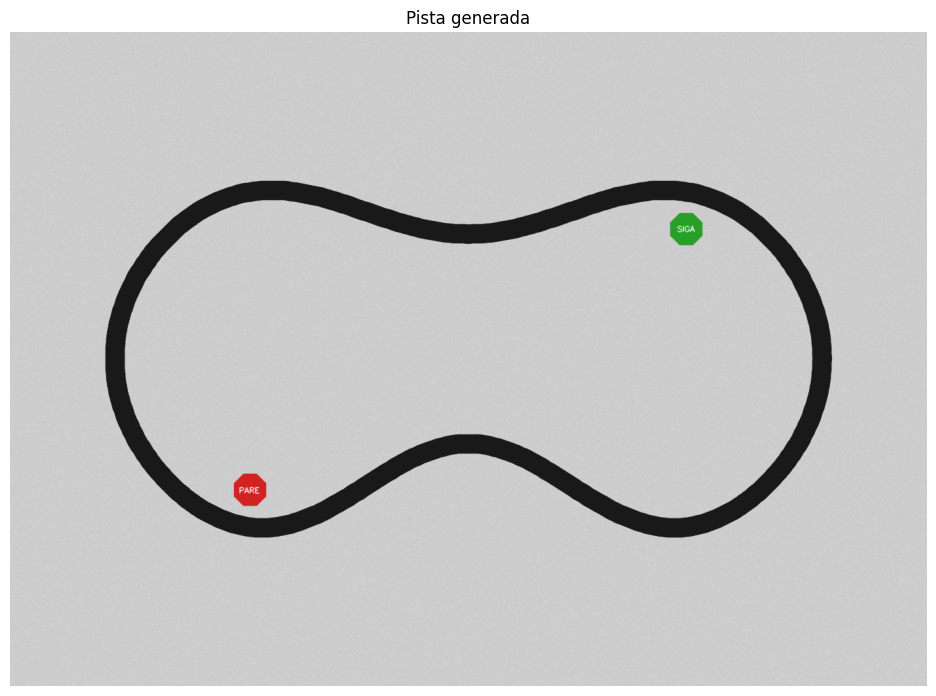

In [8]:
def recorrido_pista(n=600):
    t = np.linspace(0, 2 * np.pi, n, endpoint=False)

    # Óvalo con dos entradas hacia adentro (abajo y arriba): así hay curvas a ambos lados
    entrada_abajo = 230 * np.exp(-((t - np.pi / 2) / 0.45) ** 2)
    entrada_arriba = 170 * np.exp(-((t - 3 * np.pi / 2) / 0.5) ** 2)

    x = MAPA_ANCHO / 2 + 540 * np.cos(t)
    y = MAPA_ALTO / 2 + 360 * np.sin(t) - entrada_abajo + entrada_arriba

    return np.stack([x, y], axis=1)


def octagono(centro, radio, angulo=0.0):
    t = angulo + np.deg2rad(22.5) + 2 * np.pi * np.arange(8) / 8
    puntos = np.stack([centro[0] + radio * np.cos(t), centro[1] + radio * np.sin(t)], axis=1)
    return puntos.astype(np.int32)


def generar_pista(semilla=0):
    generador = np.random.default_rng(semilla)

    mapa = np.full((MAPA_ALTO, MAPA_ANCHO, 3), 205, np.int16)
    mapa += generador.integers(-7, 8, size=mapa.shape, dtype=np.int16)
    mapa = np.clip(mapa, 0, 255).astype(np.uint8)

    puntos = recorrido_pista()
    curva = puntos.astype(np.int32).reshape(-1, 1, 2)

    cv2.polylines(mapa, [curva], True, (25, 25, 25), GROSOR_LINEA, cv2.LINE_AA)

    # Señales al lado derecho de la línea (según el sentido de avance)
    senales = [(0.36, (35, 35, 210), "PARE"), (0.86, (40, 160, 40), "SIGA")]

    for fraccion, color, texto in senales:
        i = int(fraccion * len(puntos))
        p = puntos[i]
        tangente = puntos[(i + 1) % len(puntos)] - puntos[i - 1]
        tangente /= np.linalg.norm(tangente)
        derecha = np.array([-tangente[1], tangente[0]])

        centro = p + derecha * (GROSOR_LINEA / 2 + RADIO_SENAL + 16)
        cv2.fillPoly(mapa, [octagono(centro, RADIO_SENAL)], color, cv2.LINE_AA)

        (tw, th), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.putText(mapa, texto, (int(centro[0] - tw / 2), int(centro[1] + th / 2)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

    # Posición inicial: sobre la línea, mirando en el sentido de avance
    inicio = puntos[0]
    direccion = puntos[1] - puntos[0]
    angulo_inicio = np.arctan2(direccion[1], direccion[0])

    return mapa, puntos, (inicio[0], inicio[1], angulo_inicio)


mapa, puntos_pista, pose_inicio = generar_pista()

plt.figure(figsize=(12, 8.5))
plt.imshow(cv2.cvtColor(mapa, cv2.COLOR_BGR2RGB))
plt.title("Pista generada")
plt.axis("off")
plt.show()

## El robot y su cámara

**Movimiento (tracción diferencial).** Con la velocidad de cada llanta:

$$v = \frac{v_{izq} + v_{der}}{2} \qquad \omega = \frac{v_{izq} - v_{der}}{\text{distancia entre llantas}}$$

* $v$ es el avance y $\omega$ el giro.
* Si la izquierda va más rápido, el robot gira a la derecha.
* Si una llanta va hacia adelante y la otra hacia atrás, gira sobre sí mismo.

**Cuadro de vista.** La cámara mira hacia adelante y hacia abajo, así que ve un **trapecio** del piso: angosto cerca del robot y más ancho lejos. Ese trapecio se recorta del mapa con una **transformación de perspectiva** (`cv2.getPerspectiveTransform` + `cv2.warpPerspective`) y se convierte en una imagen de 640×480. Esa imagen es **lo único que recibe el cerebro**.

A la imagen se le agrega ruido para que se parezca a una cámara real.

In [9]:
class Robot:
    def __init__(self, x, y, angulo):
        self.x, self.y, self.angulo = float(x), float(y), float(angulo)

    def vectores(self):
        adelante = np.array([np.cos(self.angulo), np.sin(self.angulo)])
        derecha = np.array([-np.sin(self.angulo), np.cos(self.angulo)])
        return np.array([self.x, self.y]), adelante, derecha

    def mover(self, izq, der, dt):
        v = (izq + der) / 2 * ESCALA_VEL
        w = (izq - der) * ESCALA_VEL / DIST_LLANTAS

        self.angulo += w * dt
        self.x += v * np.cos(self.angulo) * dt
        self.y += v * np.sin(self.angulo) * dt

    def cuadro_de_vista(self):
        # Las 4 esquinas del trapecio en el mapa: lejos-izq, lejos-der, cerca-der, cerca-izq
        p, adelante, derecha = self.vectores()

        return np.float32([
            p + adelante * CAM_LEJOS - derecha * CAM_ANCHO_LEJOS / 2,
            p + adelante * CAM_LEJOS + derecha * CAM_ANCHO_LEJOS / 2,
            p + adelante * CAM_CERCA + derecha * CAM_ANCHO_CERCA / 2,
            p + adelante * CAM_CERCA - derecha * CAM_ANCHO_CERCA / 2,
        ])

    def camara(self, mapa, generador):
        esquinas_imagen = np.float32([[0, 0], [CAM_W, 0], [CAM_W, CAM_H], [0, CAM_H]])
        M = cv2.getPerspectiveTransform(self.cuadro_de_vista(), esquinas_imagen)

        imagen = cv2.warpPerspective(mapa, M, (CAM_W, CAM_H), borderValue=(205, 205, 205))

        # Ruido de cámara
        ruido = generador.normal(0, 4, imagen.shape)
        return np.clip(imagen + ruido, 0, 255).astype(np.uint8)

    def dibujar(self, img):
        p, adelante, derecha = self.vectores()

        cv2.polylines(img, [self.cuadro_de_vista().astype(np.int32)], True, (255, 200, 0), 2)

        cuerpo = cv2.boxPoints(((self.x, self.y), (60, 44), np.degrees(self.angulo)))
        cv2.fillPoly(img, [cuerpo.astype(np.int32)], (200, 120, 30))

        for lado in (-1, 1):
            centro = p + derecha * lado * DIST_LLANTAS / 2
            a = (centro - adelante * 13).astype(int)
            b = (centro + adelante * 13).astype(int)
            cv2.line(img, tuple(a), tuple(b), (20, 20, 20), 8)

        punta = (p + adelante * 35).astype(int)
        cv2.arrowedLine(img, tuple(p.astype(int)), tuple(punta), (255, 255, 255), 3, tipLength=0.4)

## Simulación

En cada paso:

1. El robot toma una foto (el cuadro de vista).
2. El **cerebro** la analiza y decide la velocidad de las llantas.
3. El robot se mueve durante `DT` segundos con esas velocidades.

También se lleva la cuenta de lo que evalúa la competencia: tiempo, vueltas, paradas en PARE, señales SIGA y **descarrilamientos**. Un descarrilamiento se cuenta cuando el robot se aleja de la línea más de `LIMITE_DESCARRILA`; esa distancia la mide el simulador, el cerebro no la conoce.

In [10]:
class Simulacion:
    def __init__(self, semilla=0):
        self.mapa, self.puntos, self.pose_inicio = generar_pista(semilla)
        self.curva = self.puntos.astype(np.float32).reshape(-1, 1, 2)
        self.reiniciar()

    def reiniciar(self):
        self.robot = Robot(*self.pose_inicio)
        self.cerebro = Cerebro()
        self.generador = np.random.default_rng(1)
        self.t = 0.0
        self.rastro = []
        self.historial = []
        self.paradas = 0
        self.sigas = 0
        self.descarrilamientos = 0
        self.fuera = False
        self.estado_anterior = None
        self.indice_anterior = 0
        self.avance = 0          # puntos de la pista recorridos (para contar vueltas)
        self.ultimo = None

    @property
    def vueltas(self):
        return self.avance / len(self.puntos)

    def paso(self):
        # 1. Foto  2. Pensar  3. Mover
        imagen = self.robot.camara(self.mapa, self.generador)
        r = self.cerebro.pensar(imagen, self.t)
        c = r["comando"]

        self.robot.mover(c["izq"], c["der"], DT)
        self.t += DT

        # Métricas (solo el simulador conoce la pista)
        posicion = np.array([self.robot.x, self.robot.y])
        distancias = np.linalg.norm(self.puntos - posicion, axis=1)
        indice = int(distancias.argmin())
        distancia = float(distancias[indice])

        delta = (indice - self.indice_anterior + len(self.puntos) // 2) % len(self.puntos) - len(self.puntos) // 2
        self.avance += delta
        self.indice_anterior = indice

        fuera = distancia > LIMITE_DESCARRILA
        if fuera and not self.fuera:
            self.descarrilamientos += 1
        self.fuera = fuera

        if c["estado"] != self.estado_anterior:
            if c["estado"] == "PARE":
                self.paradas += 1
            if c["estado"] == "SIGA":
                self.sigas += 1
            print(f"t = {self.t:6.2f} s  ->  {c['estado']} ({c['accion']})")
            self.estado_anterior = c["estado"]

        self.rastro.append((self.robot.x, self.robot.y))
        self.historial.append({"t": self.t, "error": r["linea"]["error"], "distancia": distancia, **c})
        self.ultimo = r

        return r

    def dibujar_mapa(self):
        img = self.mapa.copy()

        if len(self.rastro) > 1:
            cv2.polylines(img, [np.array(self.rastro, np.int32)], False, (255, 120, 0), 2)

        self.robot.dibujar(img)

        textos = [
            f"tiempo {self.t:5.1f} s   vueltas {self.vueltas:4.2f}",
            f"PARE {self.paradas}   SIGA {self.sigas}   descarrilamientos {self.descarrilamientos}",
        ]
        for k, texto in enumerate(textos):
            cv2.putText(img, texto, (20, 40 + 38 * k), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)

        return img

    def panel(self):
        # Izquierda: pista con el robot y su cuadro de vista. Derecha: lo que ve y piensa el robot.
        mapa = self.dibujar_mapa()
        alto = CAM_H
        ancho = int(MAPA_ANCHO * alto / MAPA_ALTO)
        mapa = cv2.resize(mapa, (ancho, alto), interpolation=cv2.INTER_AREA)

        vista = dibujar_cerebro(self.ultimo) if self.ultimo else np.zeros((CAM_H, CAM_W, 3), np.uint8)

        return cv2.hconcat([mapa, vista])

## Ejecutar la simulación (sin ventana)

Se simulan `SEGUNDOS` segundos y se muestran algunos momentos. Funciona también en Colab.

In [11]:
SEGUNDOS = 45

sim = Simulacion()
momentos = {}

for paso in range(int(SEGUNDOS / DT)):
    r = sim.paso()

    estado = r["comando"]["estado"]
    if estado not in momentos and estado in ("PARE", "SIGA", "BUSCANDO"):
        momentos[estado] = sim.panel()

    if paso == 60:
        momentos["SIGUIENDO"] = sim.panel()

print()
print(f"Tiempo: {sim.t:.1f} s   Vueltas: {sim.vueltas:.2f}")
print(f"Paradas en PARE: {sim.paradas}   SIGA: {sim.sigas}   Descarrilamientos: {sim.descarrilamientos}")
print(f"Distancia máxima a la línea: {max(h['distancia'] for h in sim.historial):.1f} px")

t =   0.03 s  ->  SIGUIENDO (ADELANTE)
t =   8.17 s  ->  PARE (3.0 s)
t =  11.20 s  ->  SIGUIENDO (ADELANTE)
t =  23.43 s  ->  SIGA (ADELANTE)
t =  25.00 s  ->  SIGUIENDO (ADELANTE)
t =  35.80 s  ->  PARE (3.0 s)
t =  38.83 s  ->  SIGUIENDO (ADELANTE)

Tiempo: 45.0 s   Vueltas: 1.59
Paradas en PARE: 2   SIGA: 1   Descarrilamientos: 0
Distancia máxima a la línea: 5.2 px


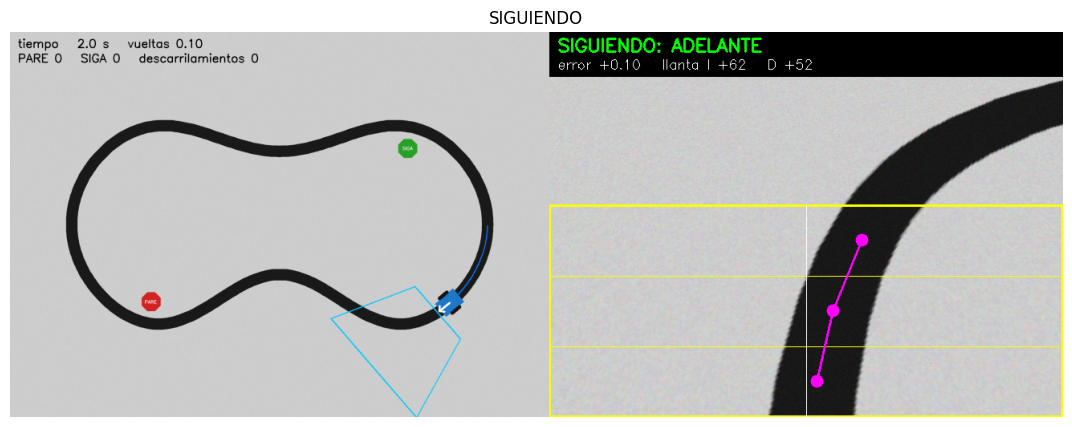

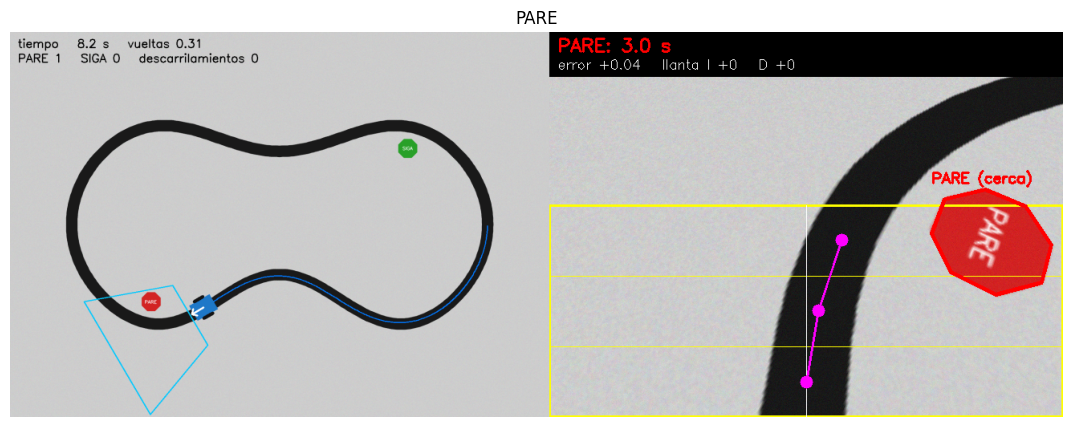

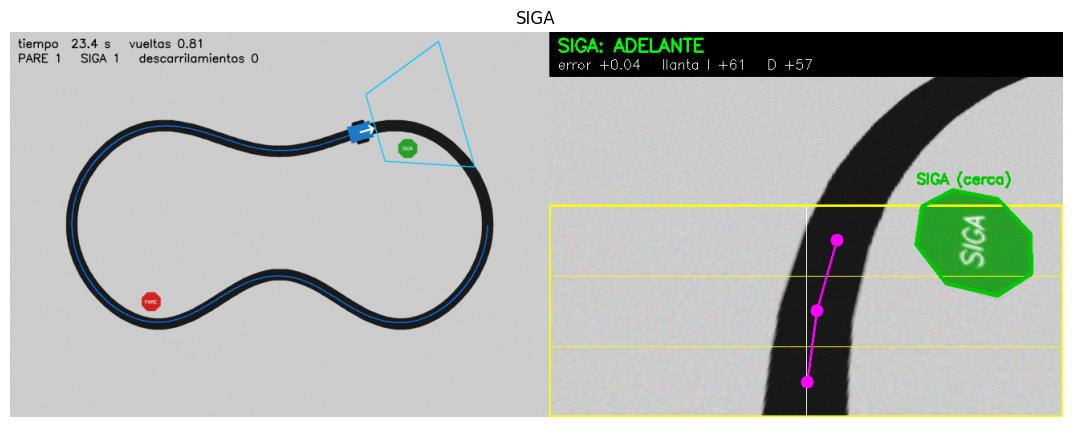

In [12]:
for nombre, img in momentos.items():
    plt.figure(figsize=(16, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(nombre)
    plt.axis("off")
    plt.show()

Recorrido completo y comportamiento de las llantas:

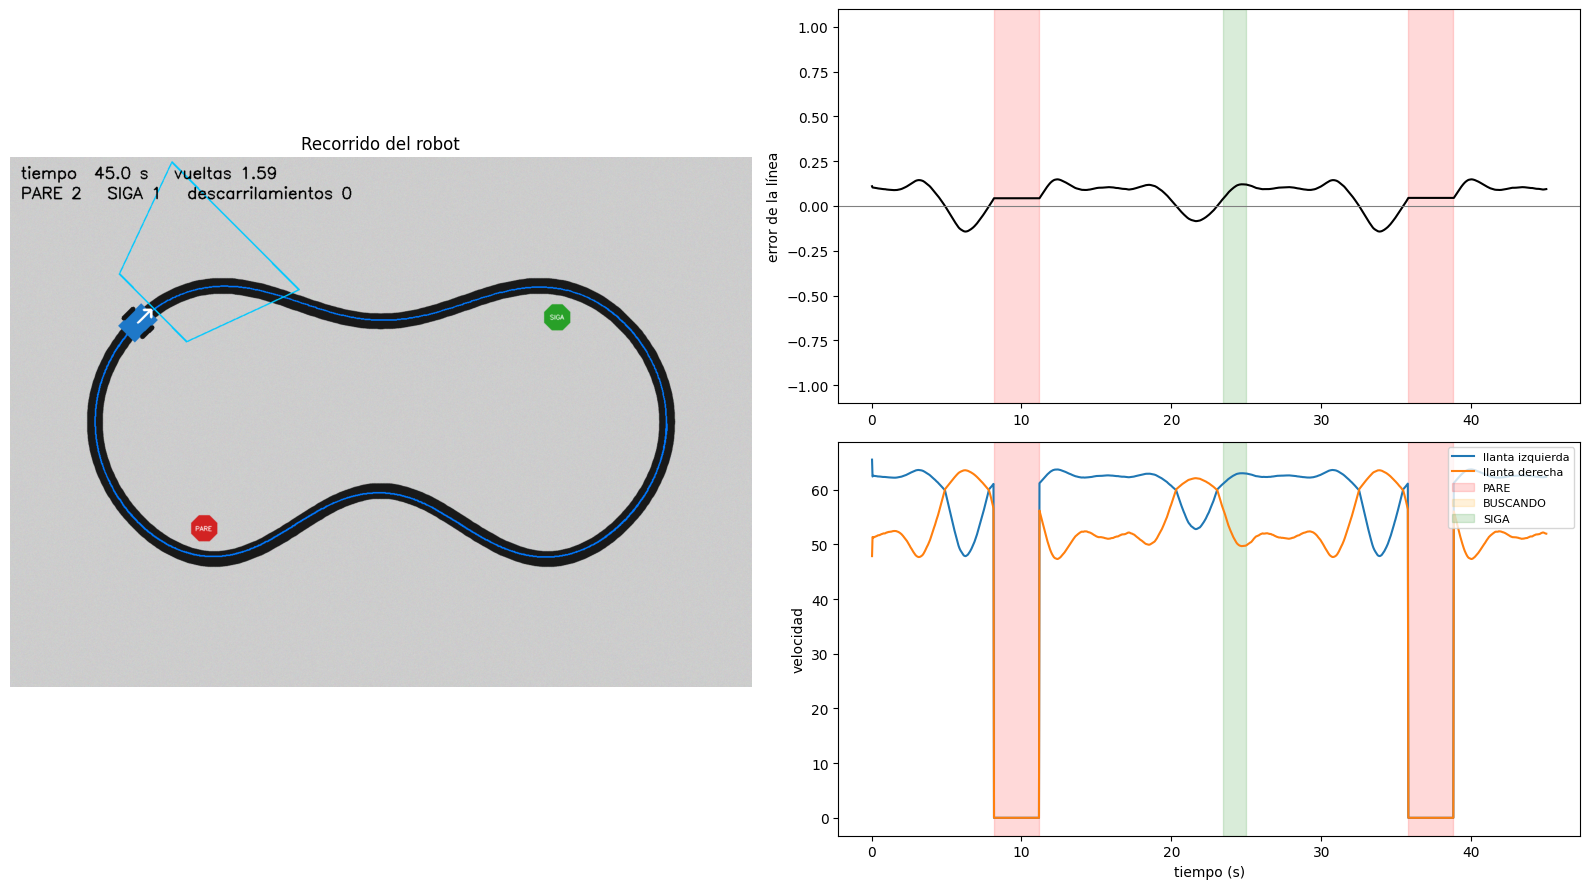

In [13]:
t = np.array([h["t"] for h in sim.historial])
estados = [h["estado"] for h in sim.historial]

fig = plt.figure(figsize=(16, 9))

eje_mapa = fig.add_subplot(1, 2, 1)
eje_mapa.imshow(cv2.cvtColor(sim.dibujar_mapa(), cv2.COLOR_BGR2RGB))
eje_mapa.set_title("Recorrido del robot")
eje_mapa.axis("off")

eje_error = fig.add_subplot(2, 2, 2)
eje_error.plot(t, [h["error"] for h in sim.historial], color="black")
eje_error.axhline(0, color="gray", lw=0.8)
eje_error.set_ylabel("error de la línea")
eje_error.set_ylim(-1.1, 1.1)

eje_llantas = fig.add_subplot(2, 2, 4, sharex=eje_error)
eje_llantas.plot(t, [h["izq"] for h in sim.historial], label="llanta izquierda")
eje_llantas.plot(t, [h["der"] for h in sim.historial], label="llanta derecha")
eje_llantas.set_ylabel("velocidad")
eje_llantas.set_xlabel("tiempo (s)")

for estado, color in (("PARE", "red"), ("BUSCANDO", "orange"), ("SIGA", "green")):
    activo = np.array([e == estado for e in estados])
    for eje in (eje_error, eje_llantas):
        eje.fill_between(t, 0, 1, where=activo, color=color, alpha=0.15,
                         transform=eje.get_xaxis_transform(), label=estado)

eje_llantas.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Simulación en vivo (ventana)

Abre la ventana **Simulador**. A la izquierda está la pista, con el robot y su cuadro de vista (trapecio celeste); a la derecha, lo que ve el robot y lo que decide.

* **P** → pausar / continuar
* **R** → reiniciar
* **+** / **-** → más rápido / más lento
* **Q** o **ESC** → salir

Solo funciona en Jupyter local (Colab no puede abrir ventanas). Haz clic en la ventana para que funcionen las teclas.

In [ ]:
if EN_COLAB:
    print("La ventana solo funciona en Jupyter local. En Colab usa la simulación sin ventana.")
else:
    sim = Simulacion()
    pausa = False
    velocidad = 1.0

    while True:
        inicio = time.monotonic()

        if not pausa:
            sim.paso()

        cv2.imshow("Simulador", sim.panel())

        # Esperar lo necesario para ir a tiempo real (DT por paso) / velocidad
        transcurrido = time.monotonic() - inicio
        espera = max(1, int((DT / velocidad - transcurrido) * 1000))
        tecla = cv2.waitKey(espera) & 0xFF

        if tecla == ord("p"):
            pausa = not pausa
        elif tecla == ord("r"):
            sim.reiniciar()
        elif tecla in (ord("+"), ord("=")):
            velocidad = min(velocidad * 2, 8)
        elif tecla == ord("-"):
            velocidad = max(velocidad / 2, 0.25)
        elif tecla in (ord("q"), 27):
            break

    cv2.destroyAllWindows()

t =   0.03 s  ->  SIGUIENDO (ADELANTE)
t =   8.17 s  ->  PARE (3.0 s)
t =  11.20 s  ->  SIGUIENDO (ADELANTE)
t =  23.43 s  ->  SIGA (ADELANTE)
t =  25.00 s  ->  SIGUIENDO (ADELANTE)
t =  35.80 s  ->  PARE (3.0 s)
t =  38.83 s  ->  SIGUIENDO (ADELANTE)
t =  51.07 s  ->  SIGA (ADELANTE)
t =  52.67 s  ->  SIGUIENDO (ADELANTE)
t =  63.40 s  ->  PARE (3.0 s)
t =  66.43 s  ->  SIGUIENDO (ADELANTE)
t =  78.67 s  ->  SIGA (ADELANTE)
t =  80.27 s  ->  SIGUIENDO (ADELANTE)
t =  91.03 s  ->  PARE (3.0 s)
t =  94.07 s  ->  SIGUIENDO (ADELANTE)
t = 106.30 s  ->  SIGA (ADELANTE)
t = 107.90 s  ->  SIGUIENDO (ADELANTE)
t = 118.63 s  ->  PARE (3.0 s)
t = 121.67 s  ->  SIGUIENDO (ADELANTE)
t = 133.90 s  ->  SIGA (ADELANTE)
t = 135.50 s  ->  SIGUIENDO (ADELANTE)
t = 146.27 s  ->  PARE (3.0 s)
t = 149.30 s  ->  SIGUIENDO (ADELANTE)
t = 161.53 s  ->  SIGA (ADELANTE)
t = 163.13 s  ->  SIGUIENDO (ADELANTE)
t = 173.87 s  ->  PARE (3.0 s)
t = 176.90 s  ->  SIGUIENDO (ADELANTE)
t = 189.13 s  ->  SIGA (ADELANTE)

# 6. Robot real: el mismo cerebro con la cámara

Cuando el robot esté armado se usa **el mismo `Cerebro`**, pero la imagen viene de la cámara en lugar del simulador:

* `FUENTE = 0` o `1` → cámara del computador.
* `FUENTE = "video.mp4"` → un video de ensayo de la carpeta de Drive del reto.
* `FUENTE = "http://IP:8080/video"` → el celular como cámara (apps *IP Webcam* o *DroidCam*).

`enviar_comando` es el puente con las llantas del mBot. Con `PUERTO_SERIAL = None` solo se simula. Para conectarlo por USB o Bluetooth, pon el puerto (por ejemplo `"COM5"`) e instala `pyserial`; el robot recibirá líneas `"izq,der"` (por ejemplo `"45,-20"`) y su programa debe leerlas y mover los motores. **Esta parte depende de cómo programen el mBot.**

In [ ]:
FUENTE = 0
PUERTO_SERIAL = None    # por ejemplo "COM5"; None = solo simulación

_puerto = None


def enviar_comando(izq, der):
    global _puerto

    if PUERTO_SERIAL is None:
        return

    if _puerto is None:
        import serial  # pip install pyserial
        _puerto = serial.Serial(PUERTO_SERIAL, 115200, timeout=0)

    _puerto.write(f"{int(izq)},{int(der)}\n".encode())


def ejecutar_real(fuente=FUENTE):
    if isinstance(fuente, int) and sys.platform == "win32":
        captura = cv2.VideoCapture(fuente, cv2.CAP_DSHOW)
    else:
        captura = cv2.VideoCapture(fuente)

    if not captura.isOpened():
        raise RuntimeError(f"No fue posible abrir la fuente {fuente!r}.")

    es_archivo = isinstance(fuente, str) and not fuente.startswith("http")
    fps = captura.get(cv2.CAP_PROP_FPS) or 30

    cerebro = Cerebro()
    indice = 0
    inicio = time.monotonic()

    while True:
        ok, cuadro = captura.read()

        if not ok:
            print("Fin del video o la cámara dejó de enviar imágenes.")
            break

        cuadro = cv2.resize(cuadro, (CAM_W, CAM_H))

        # En un video se usa el tiempo del video; en vivo, el reloj
        t = indice / fps if es_archivo else time.monotonic() - inicio
        indice += 1

        r = cerebro.pensar(cuadro, t)
        enviar_comando(r["comando"]["izq"], r["comando"]["der"])

        cv2.imshow("Robot", dibujar_cerebro(r))
        tecla = cv2.waitKey(int(1000 / fps) if es_archivo else 1) & 0xFF

        if tecla in (ord("q"), 27):
            break

    enviar_comando(0, 0)  # detener el robot al salir
    captura.release()
    cv2.destroyAllWindows()


# Descomenta para usar la cámara o un video:
# ejecutar_real(FUENTE)

# 7. Ventajas, limitaciones y mejoras

Para la comparación con los demás equipos:

**Ventajas**

* Usa HSV con dos condiciones (S y V bajas) para la línea, así las señales de color no se confunden con ella.
* Las franjas permiten anticipar curvas, y el seguimiento del centroide más cercano evita saltar a otro tramo de la pista.
* Las señales se confirman por forma (8 vértices, solidez, circularidad) y durante varios cuadros, no solo por color.
* Después de un PARE espera a que la señal salga de la vista, así no se detiene dos veces con la misma señal.
* Si pierde la línea, la busca solo, sin intervención manual.

**Limitaciones**

* Los umbrales de color dependen de la iluminación: hay que calibrar en el salón de la competencia.
* El simulador no tiene sombras, reflejos ni desenfoque por movimiento, y el robot real no responde exactamente igual.
* `KP` y `KD` dependen de la velocidad real del robot.

**Posibles mejoras**

* Usar CIELab (canal L) para la línea, que es menos sensible a cambios de luz.
* Calibrar automáticamente `V_MAX_LINEA` al inicio con K-Means (2 grupos: piso y línea).
* Estimar la curvatura con las franjas para bajar la velocidad antes de entrar en la curva.